# Neuronale Netze

In [12]:
import math

def sigmoid(z):
    return 1 / (1 + math.exp(-z))

# Hidden Layer
z_h1 = 0.7 * 0.2 + 0.35 * 0.2
z_h2 = 0.35 * 0.3 + 0.7 * 0.3
print(f"z_h1: {z_h1:.2f}")
print(f"z_h2: {z_h2:.2f}")

h1 = sigmoid(z_h1)
h2 = sigmoid(z_h2)
print(f"h1: {h1:.2f}")
print(f"h2: {h2:.2f}")

# Output Layer
z_out = 0.3 * h1 + 0.9 * h2
y = z_out   # oder sigmoid(z_out)

print(f"z_out: {z_out:.2f}")
f = y - 0.5
print(f"Fehler: {f:.2f}")

g1 = y*(1-y)*(y-0.5)
g2 = h1*(1-h1)*(0.3-g1)
g3 = h2*(1-h2)*(0.9-g1)
print(f"Gradient Sigmoid5: {g1:.2f}")
print(f"Gradient Sigmoid3: {g2:.2f}")
print(f"Gradient Sigmoid4: {g3:.2f}")


z_h1: 0.21
z_h2: 0.32
h1: 0.55
h2: 0.58
z_out: 0.69
Fehler: 0.19
Gradient Sigmoid5: 0.04
Gradient Sigmoid3: 0.06
Gradient Sigmoid4: 0.21


# Iris: Neuronale Netze

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165 (660.00 B)

 Trainable params: 165 (660.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4167 - loss: 1.0854 - val_accuracy: 0.5714 - val_loss: 0.9630
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7381 - loss: 0.8289 - val_accuracy: 0.6667 - val_loss: 0.7581
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7976 - loss: 0.6092 - val_accuracy: 0.8095 - val_loss: 0.5917
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7976 - loss: 0.4591 - val_accuracy: 0.8095 - val_loss: 0.5094
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8214 - loss: 0.3934 - val_accuracy: 0.8571 - val_loss: 0.4441
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8571 - loss: 0.3459 - val_accuracy: 0.9048 - val_loss: 0.3850
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8929 - loss: 0.3030 - val_accuracy: 0.9048 - val_loss: 0.3301
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9048 - loss: 0.2601 - val_accuracy: 0.9048 - v

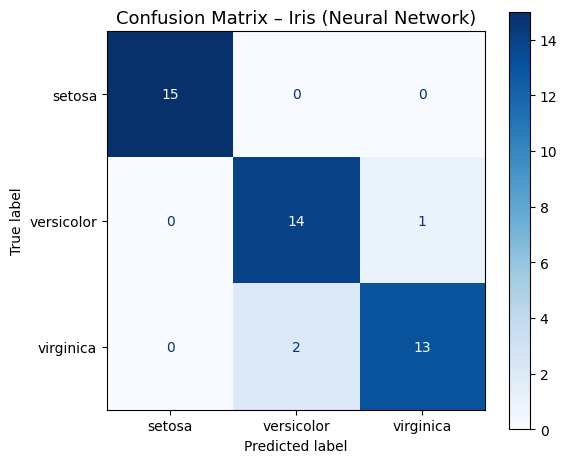

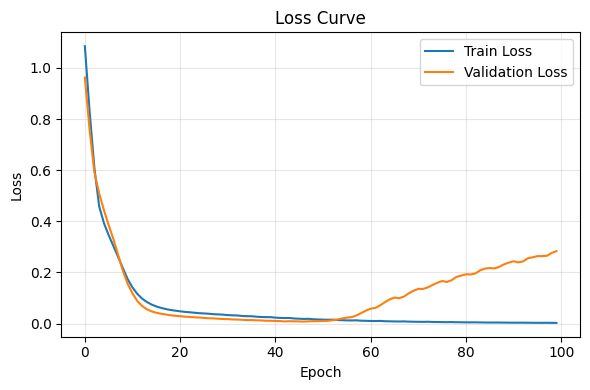

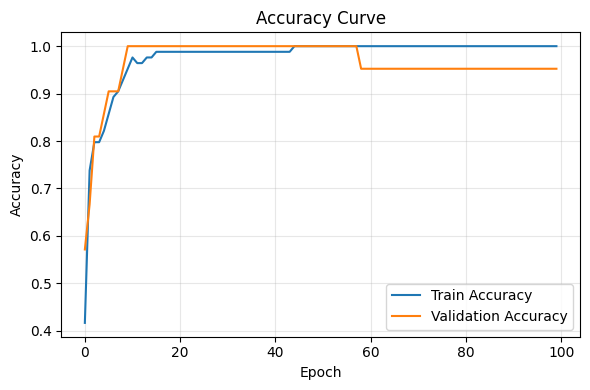

In [8]:
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) Daten laden
# =========================
data = load_iris()
X = data.data
y = data.target

# One-Hot-Encoding (3 Klassen)
encoder = OneHotEncoder(sparse_output=False)
y_one_hot = encoder.fit_transform(y.reshape(-1, 1))

# =========================
# 2) Train / Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_one_hot,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# =========================
# 3) Standardisierung
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# feste Datentypen (verhindert Retracing)
X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test  = y_test.astype(np.float32)

# =========================
# 4) Neuronales Netz
# =========================
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# =========================
# 5) Training
# =========================
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    verbose=0
)

# =========================
# 6) Evaluation
# =========================
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# =========================
# 7) Confusion Matrix (ohne Retracing)
# =========================

y_pred_proba = model(X_test, training=False).numpy()
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=True
)

ax.set_title("Confusion Matrix – Iris (Neural Network)", fontsize=13)
plt.tight_layout()
plt.show()

# =========================
# 8) Trainingskurven
# =========================
# Loss
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Accuracy
plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
